## Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import optuna

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [3]:
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Загрузка и обработка данных

In [ ]:
df_train = pd.read_csv('../dataset/atm_train_split.csv', encoding='utf-8')
df_test = pd.read_csv('../dataset/atm_test_split.csv',  encoding='utf-8')

df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=RANDOM_SEED)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)

Произведем Label Encoding для категориальных признаков для последующего кодирования через Embedding.

In [6]:
cat_cols = ['region', 'atm_group']
num_cols = [c for c in df_train.columns if c not in cat_cols + ['target']]

cat_vocabs = {}
for col in cat_cols:
    vocab = {v: i for i, v in enumerate(sorted(df_train[col].unique()))}
    cat_vocabs[col] = vocab

def encode_cats(df, cat_vocabs):
    df = df.copy()
    for col, vocab in cat_vocabs.items():
        unk_idx = len(vocab)
        df[col] = df[col].map(vocab).fillna(unk_idx).astype(int)
    return df

df_train_enc = encode_cats(df_train, cat_vocabs)
df_val_enc = encode_cats(df_val,   cat_vocabs)
df_test_enc = encode_cats(df_test,  cat_vocabs)

Нормализуем числовые признаки:

In [7]:
scaler = StandardScaler()
df_train_enc[num_cols] = scaler.fit_transform(df_train_enc[num_cols])
df_val_enc[num_cols]   = scaler.transform(df_val_enc[num_cols])
df_test_enc[num_cols]  = scaler.transform(df_test_enc[num_cols])

In [8]:
class ATMDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target_col='target'):
        self.cats = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.nums = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.targets = torch.tensor(df[target_col].values, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.cats[idx], self.nums[idx], self.targets[idx]


train_dataset = ATMDataset(df_train_enc, cat_cols, num_cols)
val_dataset   = ATMDataset(df_val_enc,   cat_cols, num_cols)
test_dataset  = ATMDataset(df_test_enc,  cat_cols, num_cols)

val_loader_fixed  = DataLoader(val_dataset,  batch_size=64, shuffle=False)
test_loader_fixed = DataLoader(test_dataset, batch_size=64, shuffle=False)

cat_vocab_sizes = [len(v) for v in cat_vocabs.values()]
print(f'Categorical vocab sizes: {dict(zip(cat_cols, cat_vocab_sizes))}')

Categorical vocab sizes: {'region': 79, 'atm_group': 7}


In [9]:
def test_performance(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'\nTest Performance:')
    print(f'   RMSE: {rmse:.4f}')
    print(f'   MAE:  {mae:.4f}')
    print(f'   R2:   {r2:.3f}')


def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for cats, nums, _ in loader:
            cats, nums = cats.to(DEVICE), nums.to(DEVICE)
            preds.extend(model(cats, nums).cpu().numpy())
    return np.array(preds)

## Полносвязная нейросеть с эмбеддингами для категориальных признаков

Архитектура:
- Embedding слои для `region` и `atm_group`;
- Конкатенация embedding'ов и числовых признаков;
- Блоки Linear → BatchNorm → ReLU → Dropout;
- Финальный линейный слой.

In [10]:
class FC_embeddings(nn.Module):
    
    def __init__(self, cat_vocab_sizes, num_numeric, emb_dims=None, hidden_dims=None, dropout=0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [128, 64, 32]
        if emb_dims is None:
            emb_dims = [min(50, (n + 1) // 2) for n in cat_vocab_sizes]

        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size + 1, emb_dim)
            for vocab_size, emb_dim in zip(cat_vocab_sizes, emb_dims)
        ])

        input_dim = sum(emb_dims) + num_numeric
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers += [
                nn.Linear(in_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, cats, nums):
        embs = [emb(cats[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [nums], dim=1)
        return self.network(x).squeeze(1)

При обучении воспользуемся планировщиком `ReduceLROnPlateau` для динамического изменения скорости обучения при отсутствии улучшения метрики на валидации. Также добавим раннюю остановку для предотвращения переобучения.

In [11]:
def train_model(model, train_loader, val_loader, n_epochs=150, lr=1e-3, early_stopping=15, log_every=10, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        batch_losses = []
        for cats, nums, targets in train_loader:
            cats, nums, targets = cats.to(DEVICE), nums.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(cats, nums), targets)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_losses.append(float(np.mean(batch_losses)))

        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for cats, nums, targets in val_loader:
                cats, nums, targets = cats.to(DEVICE), nums.to(DEVICE), targets.to(DEVICE)
                batch_val_losses.append(criterion(model(cats, nums), targets).item())

        val_loss = float(np.mean(batch_val_losses))
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if verbose and epoch % log_every == 0:
            print(f'Epoch {epoch:>4} | train_loss: {train_losses[-1]:.4f} | val_loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= early_stopping:
                if verbose:
                    print(f'Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses

In [12]:
def plot_losses(train_losses, val_losses, title='Training curve'):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train loss')
    plt.plot(val_losses,   label='Val loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Модель с дефолтными гиперпараметрами:

In [13]:
model = FC_embeddings(cat_vocab_sizes, len(num_cols)).to(DEVICE)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [15]:
%%time
model, train_losses, val_losses = train_model(model, train_loader, val_loader_fixed)

Epoch   10 | train_loss: 0.0055 | val_loss: 0.0042
Epoch   20 | train_loss: 0.0033 | val_loss: 0.0026
Epoch   30 | train_loss: 0.0031 | val_loss: 0.0024
Epoch   40 | train_loss: 0.0028 | val_loss: 0.0023
Epoch   50 | train_loss: 0.0027 | val_loss: 0.0023
Epoch   60 | train_loss: 0.0026 | val_loss: 0.0023
Epoch   70 | train_loss: 0.0025 | val_loss: 0.0023
Epoch   80 | train_loss: 0.0025 | val_loss: 0.0023
Epoch   90 | train_loss: 0.0024 | val_loss: 0.0023
Epoch  100 | train_loss: 0.0024 | val_loss: 0.0023
Epoch  110 | train_loss: 0.0024 | val_loss: 0.0022
Early stopping at epoch 110
CPU times: user 13.4 s, sys: 1.74 s, total: 15.1 s
Wall time: 15.7 s


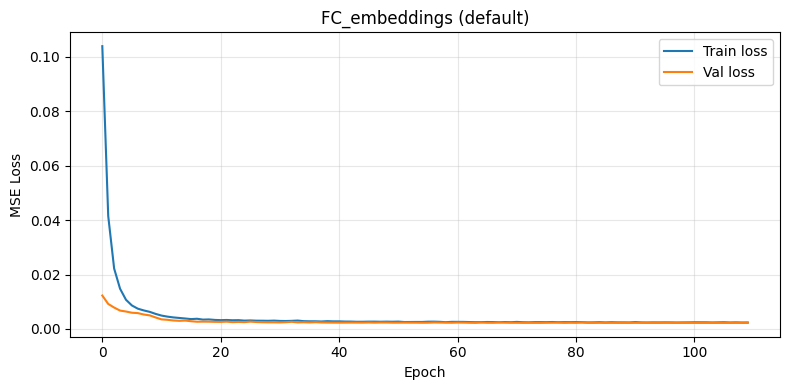

In [16]:
plot_losses(train_losses, val_losses, title='FC_embeddings (default)')

In [39]:
test_preds = predict(model, test_loader_fixed)
test_performance(test_dataset.targets.numpy(), test_preds)


Test Performance:
   RMSE: 0.0446
   MAE:  0.0358
   R2:   0.740


**Промежуточные результаты:**
- RMSE: 0.0446
- MAE: 0.0358
- R²: 0.74

**Время обучения:** 15.7 секунд

Оптимизация гиперпараметров

In [ ]:
def objective_fc_emb(trial):
    n_layers = trial.suggest_int('n_layers', 2, 5)
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256, 512])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )
    model = FC_embeddings(
        cat_vocab_sizes=cat_vocab_sizes,
        num_numeric=len(num_cols),
        hidden_dims=[hidden_dim] * n_layers,
        dropout=dropout,
    ).to(DEVICE)
    model, _, _ = train_model(model, train_loader, val_loader_fixed, lr=lr, verbose=False)
    preds = predict(model, val_loader_fixed)
    return root_mean_squared_error(df_val['target'].values, preds)


study_fc = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_fc.optimize(objective_fc_emb, n_trials=50, show_progress_bar=True)

print(f'Best Val RMSE: {study_fc.best_value:.4f}')
print(f'Best params:   {study_fc.best_params}')

Best trial: 7. Best value: 0.0440909: 100%|██████████| 50/50 [15:28<00:00, 18.57s/it]

Best Val RMSE: 0.0441
Best params:   {'n_layers': 5, 'hidden_dim': 256, 'dropout': 0.3916028672163949, 'lr': 0.0034877126245459306, 'batch_size': 64}


Epoch   10 | train_loss: 0.0047 | val_loss: 0.0031
Epoch   20 | train_loss: 0.0033 | val_loss: 0.0033
Epoch   30 | train_loss: 0.0029 | val_loss: 0.0024
Epoch   40 | train_loss: 0.0027 | val_loss: 0.0023
Epoch   50 | train_loss: 0.0026 | val_loss: 0.0023
Epoch   60 | train_loss: 0.0024 | val_loss: 0.0022
Epoch   70 | train_loss: 0.0023 | val_loss: 0.0022
Epoch   80 | train_loss: 0.0022 | val_loss: 0.0021
Epoch   90 | train_loss: 0.0022 | val_loss: 0.0022
Epoch  100 | train_loss: 0.0022 | val_loss: 0.0021
Epoch  110 | train_loss: 0.0021 | val_loss: 0.0021
Epoch  120 | train_loss: 0.0020 | val_loss: 0.0021
Early stopping at epoch 127


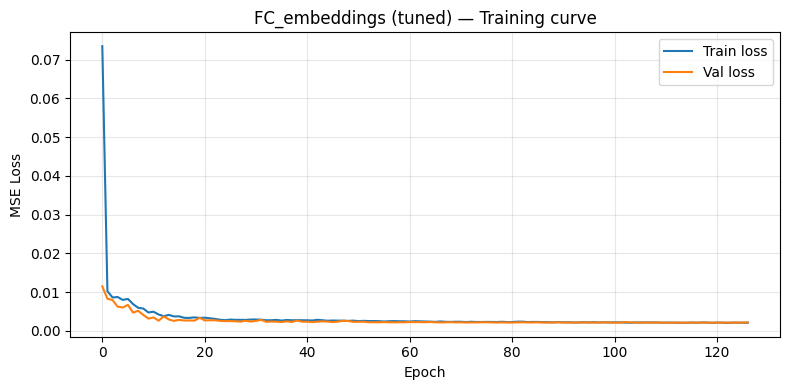


Test Performance:
   RMSE: 0.0442
   MAE:  0.0354
   R2:   0.744


In [ ]:
best_p = study_fc.best_params

best_train_loader = DataLoader(
    train_dataset, batch_size=best_p['batch_size'], shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)
best_mlp = FC_embeddings(
    cat_vocab_sizes=cat_vocab_sizes,
    num_numeric=len(num_cols),
    hidden_dims=[best_p['hidden_dim']] * best_p['n_layers'],
    dropout=best_p['dropout'],
).to(DEVICE)

best_mlp, train_losses, val_losses = train_model(best_mlp, best_train_loader, val_loader_fixed, lr=best_p['lr'])
plot_losses(train_losses, val_losses, title='FC_embeddings (tuned) — Training curve')

y_pred_mlp = predict(best_mlp, test_loader_fixed)
test_performance(df_test['target'].values, y_pred_mlp)

**Результаты:**
- RMSE: 0.0442
- MAE: 0.0354
- R²: 0.744

**Лучшие параметры:**
- n_layers: 5
- hidden_dim: 256
- dropout: 0.39
- lr: 0.00348
- batch_size: 64

**Вывод:**
- Модель с эмбеддингами для категориальных признаков показала результат лучший, чем у линейных моделей, но не превосходящий результат любой из нелинейных моделей классического ML, рассмотренных в предыдущих экспериментах.

## ResNet

Создадим ResNet архитектуру на основе предыдущей модели.

Архитектура:
- Embedding слои для `region` и `atm_group` (аналогично FC_embeddings);
- Входной проекционный выравнивает размерность для корректной работы остаточных блоков;
- Остаточные блоки: **Linear → BatchNorm → ReLU → Dropout → Linear** + прибавление входа блока;
- Финальный линейный слой.

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class ResNet(nn.Module):
    def __init__(self, cat_vocab_sizes, num_numeric, emb_dims=None, hidden_dim=256, n_blocks=4, dropout=0.3):
        super().__init__()
        if emb_dims is None:
            emb_dims = [min(50, (n + 1) // 2) for n in cat_vocab_sizes]
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size + 1, emb_dim)
            for vocab_size, emb_dim in zip(cat_vocab_sizes, emb_dims)
        ])
        input_dim = sum(emb_dims) + num_numeric
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)])
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, cats, nums):
        embs = [emb(cats[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [nums], dim=1)
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.head(x).squeeze(1)

Модель с дефолтными гиперпараметрами:

In [21]:
resnet_model = ResNet(cat_vocab_sizes, len(num_cols)).to(DEVICE)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [22]:
%%time
resnet_model, train_losses, val_losses = train_model(resnet_model, train_loader, val_loader_fixed)

Epoch   10 | train_loss: 0.0075 | val_loss: 0.0042
Epoch   20 | train_loss: 0.0046 | val_loss: 0.0029
Epoch   30 | train_loss: 0.0031 | val_loss: 0.0030
Epoch   40 | train_loss: 0.0027 | val_loss: 0.0026
Epoch   50 | train_loss: 0.0023 | val_loss: 0.0024
Epoch   60 | train_loss: 0.0022 | val_loss: 0.0023
Epoch   70 | train_loss: 0.0021 | val_loss: 0.0023
Epoch   80 | train_loss: 0.0020 | val_loss: 0.0023
Early stopping at epoch 88
CPU times: user 18 s, sys: 2.05 s, total: 20 s
Wall time: 20.1 s


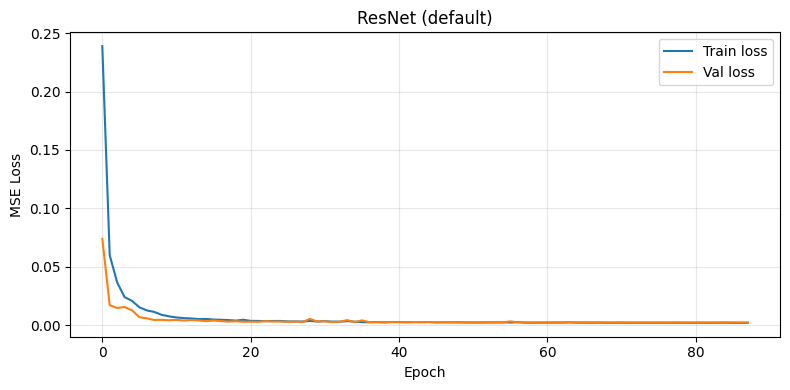

In [23]:
plot_losses(train_losses, val_losses, title='ResNet (default)')

In [21]:
test_preds = predict(resnet_model, test_loader_fixed)
test_performance(test_dataset.targets.numpy(), test_preds)


Test Performance:
   RMSE: 0.0449
   MAE:  0.0360
   R2:   0.736


**Промежуточные результаты:**
- RMSE: 0.0449
- MAE: 0.036
- R²: 0.736

**Время обучения:** 20.1 секунд

### Оптимизация гиперпараметров

In [22]:
def objective_resnet(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256, 512])
    n_blocks = trial.suggest_int('n_blocks', 2, 8)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )
    model = ResNet(
        cat_vocab_sizes=cat_vocab_sizes,
        num_numeric=len(num_cols),
        hidden_dim=hidden_dim,
        n_blocks=n_blocks,
        dropout=dropout,
    ).to(DEVICE)
    model, _, _ = train_model(model, train_loader, val_loader_fixed, lr=lr, verbose=False)
    preds = predict(model, val_loader_fixed)
    return root_mean_squared_error(df_val['target'].values, preds)


study_resnet = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_resnet.optimize(objective_resnet, n_trials=50, show_progress_bar=True)


print(f'Best Val RMSE: {study_resnet.best_value:.4f}')
print(f'Best params:   {study_resnet.best_params}')

Best trial: 32. Best value: 0.0447122: 100%|██████████| 50/50 [32:14<00:00, 38.69s/it]

Best Val RMSE: 0.0447
Best params:   {'hidden_dim': 128, 'n_blocks': 7, 'dropout': 0.22960509833621778, 'lr': 0.002333448684516477, 'batch_size': 32}


Epoch   10 | train_loss: 0.0055 | val_loss: 0.0036
Epoch   20 | train_loss: 0.0038 | val_loss: 0.0029
Epoch   30 | train_loss: 0.0029 | val_loss: 0.0026
Epoch   40 | train_loss: 0.0026 | val_loss: 0.0026
Epoch   50 | train_loss: 0.0021 | val_loss: 0.0023
Epoch   60 | train_loss: 0.0021 | val_loss: 0.0023
Early stopping at epoch 66


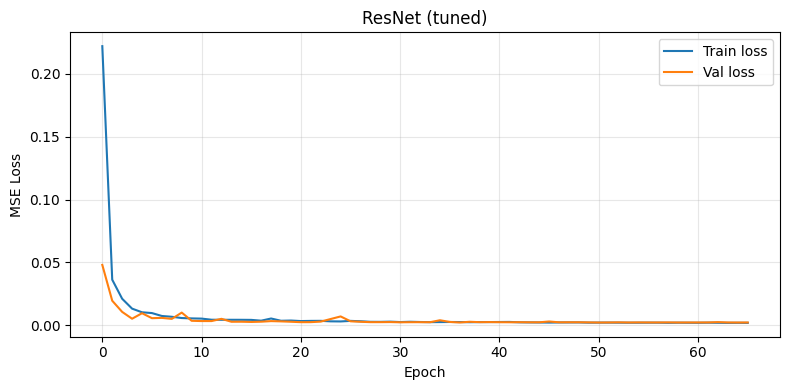


Test Performance:
   RMSE: 0.0442
   MAE:  0.0351
   R2:   0.745


In [23]:
best_p = study_resnet.best_params

best_train_loader = DataLoader(
    train_dataset, batch_size=best_p['batch_size'], shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)
best_resnet = ResNet(
    cat_vocab_sizes=cat_vocab_sizes,
    num_numeric=len(num_cols),
    hidden_dim=best_p['hidden_dim'],
    n_blocks=best_p['n_blocks'],
    dropout=best_p['dropout'],
).to(DEVICE)

best_resnet, train_losses, val_losses = train_model(best_resnet, best_train_loader, val_loader_fixed, lr=best_p['lr'])
plot_losses(train_losses, val_losses, title='ResNet (tuned)')

y_pred_resnet = predict(best_resnet, test_loader_fixed)
test_performance(df_test['target'].values, y_pred_resnet)


**Результаты:**
- RMSE: 0.0442
- MAE: 0.0351
- R²: 0.745

**Лучшие параметры:**
- hidden_dim: 128
- n_blocks: 7
- dropout: 0.23
- lr: 0.0023
- batch_size: 32

**Вывод:**
- После подбора гиперпараметров ResNet модель показала результат почти не отличимый от предыдущей модели с эмбеддингами;
- ResNet архитектура является более сложной, требует больше времени на обучение и подбор гиперпараметров.

## FT-Transformer (Feature Tokenizer + Transformer)

Каждый признак преобразуется в вектор фиксированной размерности (`d_model`):
- Числовые признаки: линейная проекция `Linear(1, d_model)` + смещение (bias-вектор) — по одному обучаемому bias на каждый числовой признак;
- Категориальные признаки: `nn.Embedding(vocab_size + 1, d_model)`.

Все токены-признаки конкатенируются с обучаемым `[CLS]`-токеном и подаются в стек слоёв `TransformerEncoderLayer` (Multi-Head Attention + FFN + LayerNorm).

Выход `[CLS]`-токена после трансформера проходит через финальный линейный слой для предсказания целевой переменной.

In [24]:
class FTTransformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        num_numeric,
        d_model=64,
        n_heads=8,
        n_layers=3,
        ffn_factor=4,
        dropout=0.1,
    ):
        super().__init__()
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab_size + 1, d_model)
            for vocab_size in cat_vocab_sizes
        ])
        self.num_weights = nn.Parameter(torch.empty(num_numeric, d_model))
        self.num_biases  = nn.Parameter(torch.empty(num_numeric, d_model))
        nn.init.kaiming_uniform_(self.num_weights, a=np.sqrt(5))
        nn.init.zeros_(self.num_biases)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * ffn_factor,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, cats, nums):
        num_tokens = nums.unsqueeze(-1) * self.num_weights.unsqueeze(0) + self.num_biases.unsqueeze(0)
        cat_tokens = torch.stack(
            [emb(cats[:, i]) for i, emb in enumerate(self.cat_embeddings)],
            dim=1,
        )
        cls = self.cls_token.expand(cats.size(0), -1, -1)
        x = torch.cat([cls, cat_tokens, num_tokens], dim=1)
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x).squeeze(1)


Модель с дефолтными гиперпараметрами:

In [25]:
ft_model = FTTransformer(cat_vocab_sizes, len(num_cols)).to(DEVICE)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [26]:
%%time
ft_model, train_losses, val_losses = train_model(ft_model, train_loader, val_loader_fixed)

Epoch   10 | train_loss: 0.0033 | val_loss: 0.0025
Epoch   20 | train_loss: 0.0026 | val_loss: 0.0024
Epoch   30 | train_loss: 0.0026 | val_loss: 0.0030
Epoch   40 | train_loss: 0.0024 | val_loss: 0.0025
Epoch   50 | train_loss: 0.0022 | val_loss: 0.0022
Epoch   60 | train_loss: 0.0020 | val_loss: 0.0023
Epoch   70 | train_loss: 0.0019 | val_loss: 0.0024
Early stopping at epoch 79
CPU times: user 24.1 s, sys: 2.35 s, total: 26.4 s
Wall time: 26.4 s


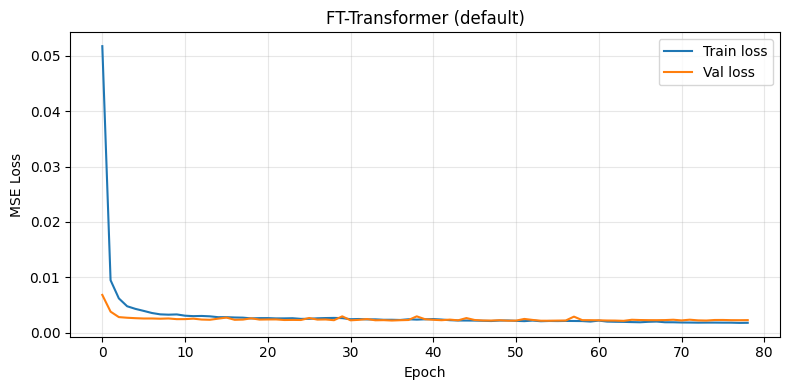

In [27]:
plot_losses(train_losses, val_losses, title='FT-Transformer (default)')

In [26]:
test_preds = predict(ft_model, test_loader_fixed)
test_performance(test_dataset.targets.numpy(), test_preds)


Test Performance:
   RMSE: 0.0447
   MAE:  0.0357
   R2:   0.738


**Промежуточные результаты:**
- RMSE: 0.0447
- MAE: 0.0357
- R²: 0.738

**Время обучения:** 26.4 секунд

### Оптимизация гиперпараметров

In [28]:
def objective_ft(trial):
    d_model    = trial.suggest_categorical('d_model', [32, 64, 128, 256])
    n_heads    = trial.suggest_categorical('n_heads', [2, 4, 8])
    n_layers   = trial.suggest_int('n_layers', 1, 4)
    ffn_factor = trial.suggest_categorical('ffn_factor', [2, 4])
    dropout    = trial.suggest_float('dropout', 0.0, 0.3)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )
    model = FTTransformer(
        cat_vocab_sizes=cat_vocab_sizes,
        num_numeric=len(num_cols),
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        ffn_factor=ffn_factor,
        dropout=dropout,
    ).to(DEVICE)
    model, _, _ = train_model(model, train_loader, val_loader_fixed, lr=lr, verbose=False)
    preds = predict(model, val_loader_fixed)
    return root_mean_squared_error(df_val['target'].values, preds)


study_ft = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_ft.optimize(objective_ft, n_trials=50, show_progress_bar=True)

print(f'Best Val RMSE: {study_ft.best_value:.4f}')
print(f'Best params:   {study_ft.best_params}')


Best trial: 23. Best value: 0.0441722: 100%|██████████| 50/50 [20:43<00:00, 24.88s/it]

Best Val RMSE: 0.0442
Best params:   {'d_model': 256, 'n_heads': 2, 'n_layers': 3, 'ffn_factor': 2, 'dropout': 0.04025969824863472, 'lr': 0.00043542095369915134, 'batch_size': 64}


Epoch   10 | train_loss: 0.0042 | val_loss: 0.0022
Epoch   20 | train_loss: 0.0030 | val_loss: 0.0023
Epoch   30 | train_loss: 0.0027 | val_loss: 0.0024
Epoch   40 | train_loss: 0.0025 | val_loss: 0.0021
Epoch   50 | train_loss: 0.0024 | val_loss: 0.0021
Epoch   60 | train_loss: 0.0024 | val_loss: 0.0022
Epoch   70 | train_loss: 0.0024 | val_loss: 0.0021
Epoch   80 | train_loss: 0.0024 | val_loss: 0.0021
Epoch   90 | train_loss: 0.0024 | val_loss: 0.0021
Epoch  100 | train_loss: 0.0024 | val_loss: 0.0021
Early stopping at epoch 104


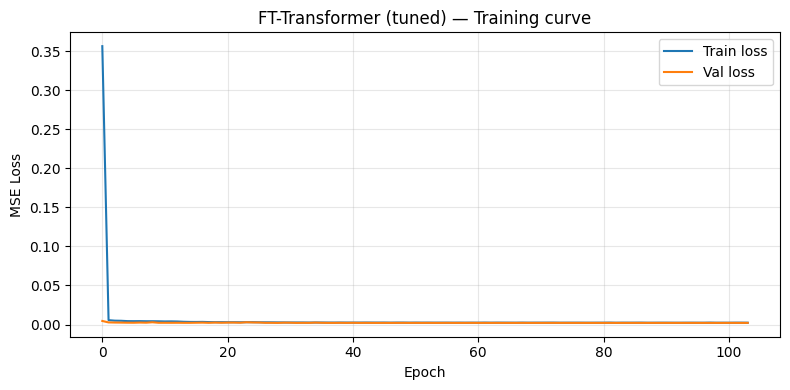


Test Performance:
   RMSE: 0.0446
   MAE:  0.0352
   R2:   0.740


In [29]:
best_p = study_ft.best_params

best_train_loader = DataLoader(
    train_dataset, batch_size=best_p['batch_size'], shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)
best_ft = FTTransformer(
    cat_vocab_sizes=cat_vocab_sizes,
    num_numeric=len(num_cols),
    d_model=best_p['d_model'],
    n_heads=best_p['n_heads'],
    n_layers=best_p['n_layers'],
    ffn_factor=best_p['ffn_factor'],
    dropout=best_p['dropout'],
).to(DEVICE)

best_ft, train_losses, val_losses = train_model(best_ft, best_train_loader, val_loader_fixed, lr=best_p['lr'])
plot_losses(train_losses, val_losses, title='FT-Transformer (tuned) — Training curve')

y_pred_ft = predict(best_ft, test_loader_fixed)
test_performance(df_test['target'].values, y_pred_ft)


**Результаты:**
- RMSE: 0.0446
- MAE: 0.0352
- R²: 0.740

**Лучшие параметры:**
- d_model: 256
- n_heads: 2
- n_layers: 3
- ffn_factor: 2
- dropout: 0.04
- lr: 0.0004
- batch_size: 64

**Вывод:**
- FT-Transformer показал худший результат среди моделей глубокого обучения, что может быть связано с недостаточным количеством данных для эффективного обучения трансформерной архитектуры;

## Выводы


| Модель | RMSE | MAE | R² | Время обучения |
|---|---|---|---|---|
| FC Embeddings | 0.0442 | 0.0354 | 0.744 | 15.7 с |
| ResNet | 0.0442 | 0.0351 | 0.745 | 20.1 с |
| FT-Transformer | 0.0446 | 0.0352 | 0.740 | 26.4 с |

- Усложнение архитектуры нейросети не привело к заметному улучшению целевых метрик


**Сравнение всех моделей** (ранжирование по RMSE):

| Модель | RMSE | MAE | R² |
|--------|------|-----|-----|
| Random Forest | 0.0432 | 0.0343 | 0.755 |
| LightGBM | 0.0437 | 0.0348 | 0.751 |
| CatBoost | 0.0438 | 0.0346 | 0.749 |
| FC Embeddings | 0.0442 | 0.0354 | 0.744 |
| ResNet | 0.0442 | 0.0351 | 0.745 |
| FT-Transformer | 0.0446 | 0.0352 | 0.740 |
| Linear Regression | 0.0452 | 0.0362 | 0.733 |
| Decision Tree | 0.0462 | 0.0372 | 0.721 |
| KNN | 0.0515 | 0.0381 | 0.653 |


- Лучшие результаты показали нелинейные модели классического машинного обучения (Random Forest, LightGBM, CatBoost);
- Худшие результаты показали наиболее простые модели (KNN, Decision Tree);
- DL модели показали результаты лучше, чем у линейной регрессии, но не смогли превзойти категориальные бустинги и случайный лес.

Слабую эффективность DL моделей можно объяснить относительно небольшим размером датасета, что не позволяет полностью раскрыть потенциал сложных архитектур. Превосходство нелинейных моделей классического ML может быть обусловлено сложной зависимостью между признаками и целевой переменной, которая лучше моделируется деревьями решений и бустингом, чем линейной регрессией или KNN.

С учетом всех рассмотренных моделей, наиболее преспективным направлением для улучшения результатов является оптимизация гиперпараметров леса и бустинга, а также дополнительный фича-инжиниринг для выявления новых признаков, которые могут лучше раскрыть закономерности в данных.